# ImageNet-256 FID trajectories

Discover ImageNet-256 training runs, evaluate checkpoints at a configurable interval, cache FID results, and plot trajectories. Device selection is delegated to the repository accelerator utilities, which prefer Intel XPU on Dawn and retain CUDA/CPU fallbacks.

The expensive sweep is restartable: valid result JSON files are reused by `evaluate_checkpoint_fidutil.py --skip-existing`. For a quick test, use 1,000 samples and one checkpoint; restore 50,000 samples for reportable FID.

In [1]:
from __future__ import annotations

import json, math, re, subprocess, sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from tqdm.auto import tqdm

here = Path.cwd().resolve()
REPO = next((p for p in (here, *here.parents) if (p / 'evaluate_checkpoint_fidutil.py').is_file()), None)
if REPO is None:
    raise FileNotFoundError('Start Jupyter inside the riesz_flow_hudson repository')
sys.path.insert(0, str(REPO))
from utils.dist_util import accelerator_type, local_device_count, xpu_is_available
from utils.env import IMAGENET_FID_NPZ

RUNS_ROOT = Path('/home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs')
RESULTS_ROOT = REPO / 'notebooks' / 'fid_imagenet256_results'
STEP_INTERVAL = 2_000
NUM_SAMPLES = 50_000
CFG_SCALES = '1.19'       # blank => all scales from each training config
GEN_BSZ_PER_DEVICE = 64
NPROC_PER_NODE = 1        # robust single-PVC default on Dawn
SEED = 0
FID_REF = ''              # blank => utils.env.IMAGENET_FID_NPZ
RUN_NAME_REGEX = r'^imagenet256_'
MAX_CHECKPOINTS = None    # e.g. 1 for a smoke test

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
device_kind = accelerator_type()
print(f'Repository: {REPO}')
print(f'Runs:       {RUNS_ROOT}')
print(f'Results:    {RESULTS_ROOT}')
print(f'Accelerator: {device_kind} ({local_device_count()} visible device(s)); XPU available={xpu_is_available()}')


/home/rc-chen1/.conda/envs/mmd_flow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: /home/rc-chen1/riesz_flow_hudson
Runs:       /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs
Results:    /home/rc-chen1/riesz_flow_hudson/artifacts/fid_imagenet256
Accelerator: xpu (2 visible device(s)); XPU available=True


## Discover checkpoints and map runs to model configs

In [2]:
CONFIG_RULES = [
    (r'ablation_drifting', 'configs/gen/imagenet256_ablation_drifting.yaml'),
    (r'ablation_sliced_riesz', 'configs/gen/imagenet256_ablation_sliced_riesz.yaml'),
    (r'ablation_sinkhorn', 'configs/gen/imagenet256_ablation_sinkhorn.yaml'),
    (r'ablation_riesz', 'configs/gen/imagenet256_ablation_riesz.yaml'),
    (r'B_sliced_riesz', 'configs/gen/imagenet256_B_sliced_riesz.yaml'),
    (r'B_sinkhorn', 'configs/gen/imagenet256_B_sinkhorn.yaml'),
    (r'B_riesz', 'configs/gen/imagenet256_B_riesz.yaml'),
    (r'ot_1node', 'configs/gen/imagenet256_ot_1node.yaml'),
]
STEP_RE = re.compile(r'^state_(\d+)\.pt$')

def config_for_run(name):
    return next(((REPO / path).resolve() for pattern, path in CONFIG_RULES if re.search(pattern, name)), None)

rows = []
for run_dir in sorted(RUNS_ROOT.iterdir()):
    if not run_dir.is_dir() or re.search(RUN_NAME_REGEX, run_dir.name) is None:
        continue
    config = config_for_run(run_dir.name)
    for checkpoint in sorted((run_dir / 'checkpoints').glob('state_*.pt')):
        match = STEP_RE.match(checkpoint.name)
        if match and int(match.group(1)) > 0 and int(match.group(1)) % STEP_INTERVAL == 0:
            rows.append({'run': run_dir.name, 'step': int(match.group(1)), 'checkpoint': checkpoint.resolve(), 'config': config})
inventory = pd.DataFrame(rows)
if inventory.empty:
    raise RuntimeError(f'No ImageNet-256 checkpoints divisible by {STEP_INTERVAL:,} under {RUNS_ROOT}')
inventory = inventory.sort_values(['run', 'step']).reset_index(drop=True)
bad = inventory[inventory['config'].map(lambda p: p is None or not p.is_file())]
display(inventory.groupby('run').agg(checkpoints=('step', 'size'), first_step=('step', 'min'), last_step=('step', 'max'), config=('config', lambda x: Path(x.iloc[0]).name)))
if not bad.empty:
    display(bad[['run', 'config']].drop_duplicates())
    raise RuntimeError('Add config mappings for unresolved runs before evaluation')
for config_path in inventory['config'].drop_duplicates():
    config_data = yaml.safe_load(config_path.read_text())
    assert int(config_data['dataset']['resolution']) == 256, config_path
fid_ref = Path(FID_REF or IMAGENET_FID_NPZ).expanduser().resolve()
with np.load(fid_ref) as stats:
    assert {'mu', 'sigma'}.issubset(stats.files), fid_ref
    assert stats['sigma'].shape == (stats['mu'].size, stats['mu'].size), fid_ref
print(f'{len(inventory)} checkpoints across {inventory.run.nunique()} runs; reference={fid_ref}')


,checkpoints,first_step,last_step,config
run,,,,
imagenet256_B_riesz_4nodes,5,2000,10000,imagenet256_B_riesz.yaml
imagenet256_B_sinkhorn_4nodes,5,2000,10000,imagenet256_B_sinkhorn.yaml
imagenet256_ablation_drifting_2nodes,2,10000,12000,imagenet256_ablation_drifting.yaml
imagenet256_ablation_sinkhorn_2nodes,2,6000,8000,imagenet256_ablation_sinkhorn.yaml


14 checkpoints across 4 runs; reference=/rds/project/rds-tfgYl93jDnM/cache/wflow_hf_root/stats/jit_in256_stats.npz


## Evaluate selected checkpoints (restartable)

In [3]:
manifest_path = RESULTS_ROOT / 'evaluation_manifest.jsonl'
items = inventory.head(MAX_CHECKPOINTS) if MAX_CHECKPOINTS else inventory
for position, (_, row) in enumerate(tqdm(items.iterrows(), total=len(items), desc='FID checkpoints', unit='checkpoint'), 1):
    command = [sys.executable, '-m', 'torch.distributed.run', f'--nproc_per_node={NPROC_PER_NODE}',
        str(REPO / 'evaluate_checkpoint_fidutil.py'), '--run-dir', str(RUNS_ROOT / row['run']),
        '--ckpt', str(row['checkpoint']), '--config', str(row['config']), '--num-samples', str(NUM_SAMPLES),
        '--gen-bsz', str(GEN_BSZ_PER_DEVICE), '--seed', str(SEED), '--fid-ref', str(fid_ref),
        '--result-dir', str(RESULTS_ROOT / row['run']), '--skip-existing']
    if CFG_SCALES.strip(): command += ['--cfg-scales', CFG_SCALES]
    print(f"\n[{position}/{len(items)}] {row['run']} @ {row['step']:,} on {device_kind}", flush=True)
    started = datetime.now(timezone.utc).isoformat()
    completed = subprocess.run(command, cwd=REPO, check=False)
    with manifest_path.open('a', encoding='utf-8') as handle:
        handle.write(json.dumps({'timestamp_utc': started, 'run': row['run'], 'step': int(row['step']), 'checkpoint': str(row['checkpoint']), 'returncode': completed.returncode}) + '\n')
    if completed.returncode: print('FAILED (recorded; continuing)', flush=True)
print(f'Finished sweep. Status log: {manifest_path}')


FID checkpoints:   0%|          | 0/14 [00:00<?, ?checkpoint/s]


[1/14] imagenet256_B_riesz_4nodes @ 2,000 on xpu


Config:       /home/rc-chen1/riesz_flow_hudson/configs/gen/imagenet256_B_riesz.yaml
Resolution:   256
Checkpoint:   /rds/project/rds-tfgYl93jDnM/runs/imagenet256_B_riesz_4nodes/checkpoints/state_00002000.pt
Reference:    /rds/project/rds-tfgYl93jDnM/cache/wflow_hf_root/stats/jit_in256_stats.npz
CFG scales:   [1.19]
Samples/CFG:  50000
Result dir:   /home/rc-chen1/riesz_flow_hudson/artifacts/fid_imagenet256/imagenet256_B_riesz_4nodes


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loaded EMA model from step 2000 (/rds/project/rds-tfgYl93jDnM/runs/imagenet256_B_riesz_4nodes/checkpoints/state_00002000.pt)
  Parameters: 132,708,880
Evaluating CFG 1.19 ...


...

E0809 18:09:36.675000 3262967 site-packages/torch/distributed/elastic/multiprocessing/api.py:1002] failed (exitcode: 1) local_rank: 0 (pid: 3262979) of binary: /home/rc-chen1/.conda/envs/mmd_flow/bin/python
Traceback (most recent call last):
  File "/home/rc-chen1/.conda/envs/mmd_flow/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/rc-chen1/.conda/envs/mmd_flow/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/rc-chen1/.conda/envs/mmd_flow/lib/python3.10/site-packages/torch/distributed/run.py", line 1032, in <module>
    main()
  File "/home/rc-chen1/.conda/envs/mmd_flow/lib/python3.10/site-packages/torch/distributed/elastic/multiprocessing/errors/__init__.py", line 367, in wrapper
    return f(*args, **kwargs)
  File "/home/rc-chen1/.conda/envs/mmd_flow/lib/python3.10/site-packages/torch/distributed/run.py", line 1028, in main
    run(args)
  File "/home/rc-chen1/.conda/envs

FAILED (recorded; continuing)


FID checkpoints: 100%|██████████| 14/14 [13:44:33<00:00, 1487.79s/checkpoint]

FID checkpoints: 100%|██████████| 14/14 [13:44:33<00:00, 3533.80s/checkpoint]

Finished sweep. Status log: /home/rc-chen1/riesz_flow_hudson/artifacts/fid_imagenet256/evaluation_manifest.jsonl


## Load cached results and plot trajectories

,run,step,cfg_scale,fid
0,imagenet256_B_riesz_4nodes,2000,1.19,227.355058
1,imagenet256_B_riesz_4nodes,4000,1.19,56.034858
2,imagenet256_B_riesz_4nodes,6000,1.19,11.765194
3,imagenet256_B_riesz_4nodes,8000,1.19,6.804313
4,imagenet256_B_riesz_4nodes,10000,1.19,5.871916
5,imagenet256_B_sinkhorn_4nodes,2000,1.19,301.388047
6,imagenet256_B_sinkhorn_4nodes,4000,1.19,40.350670
7,imagenet256_B_sinkhorn_4nodes,6000,1.19,7.564300
8,imagenet256_B_sinkhorn_4nodes,8000,1.19,4.929053
9,imagenet256_B_sinkhorn_4nodes,10000,1.19,4.278419


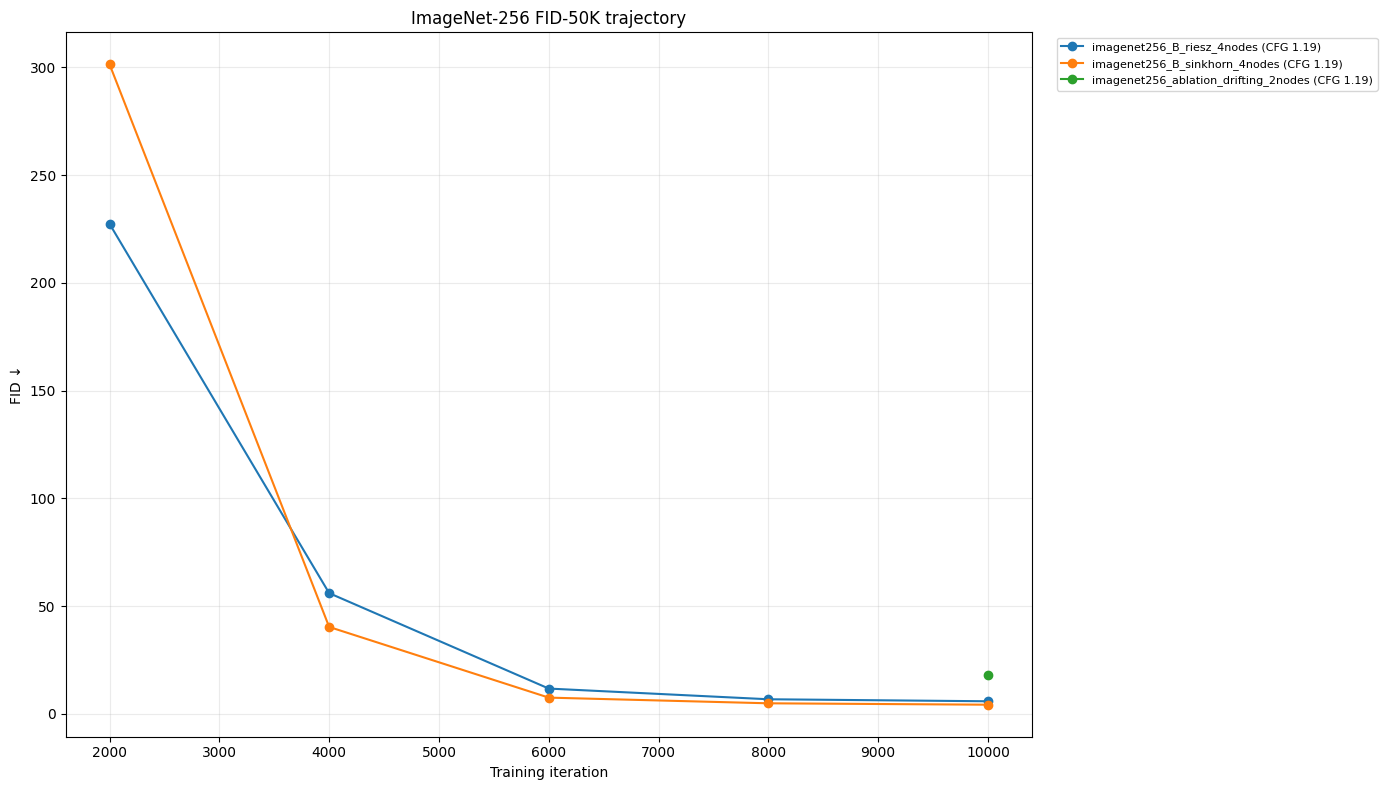

Saved /home/rc-chen1/riesz_flow_hudson/artifacts/fid_imagenet256/fid50k_trajectory.csv and /home/rc-chen1/riesz_flow_hudson/artifacts/fid_imagenet256/fid50k_trajectory.png


In [4]:
rows = []
for path in RESULTS_ROOT.glob(f'imagenet256_*/fid{NUM_SAMPLES // 1000}k_step*_cfg*.json'):
    try:
        payload = json.loads(path.read_text())
        fid = float(payload['fid'])
        if not math.isfinite(fid): raise ValueError(f'non-finite FID: {fid}')
        rows.append({'run': path.parent.name, 'step': int(payload['step']), 'cfg_scale': float(payload['cfg_scale']), 'fid': fid, 'result': path})
    except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError) as exc:
        print(f'Ignoring invalid result {path}: {exc}')
results = pd.DataFrame(rows)
if results.empty:
    print('No matching cached results yet. Run the evaluation cell above.')
else:
    results = results.sort_values(['run', 'cfg_scale', 'step']).reset_index(drop=True)
    if results.duplicated(['run', 'step', 'cfg_scale']).any(): raise RuntimeError('Duplicate FID results found')
    trajectory_path = RESULTS_ROOT / f'fid{NUM_SAMPLES // 1000}k_trajectory.csv'
    results[['run', 'step', 'cfg_scale', 'fid']].to_csv(trajectory_path, index=False)
    display(results[['run', 'step', 'cfg_scale', 'fid']])
    fig, ax = plt.subplots(figsize=(14, 8))
    for (run, cfg), group in results.groupby(['run', 'cfg_scale']):
        ax.plot(group.step, group.fid, marker='o', label=f'{run} (CFG {cfg:g})')
    ax.set(title=f'ImageNet-256 FID-{NUM_SAMPLES // 1000}K trajectory', xlabel='Training iteration', ylabel='FID ↓')
    ax.grid(alpha=.25); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8); fig.tight_layout()
    plot_path = RESULTS_ROOT / f'fid{NUM_SAMPLES // 1000}k_trajectory.png'
    fig.savefig(plot_path, dpi=180, bbox_inches='tight'); plt.show()
    print(f'Saved {trajectory_path} and {plot_path}')
